**## 1. Import Required Libraries**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully")

Libraries imported successfully


**## 2. Upload Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Task2_Superstore_EDA_Dataset.csv to Task2_Superstore_EDA_Dataset (1).csv


**## 3. Load Dataset**

In [3]:
df = pd.read_csv(
    "/content/Task2_Superstore_EDA_Dataset.csv",
    parse_dates=["Order Date", "Ship Date"]
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2014-101947,2014-01-01,2014-01-06,Standard Class,CU-0761,Mia Wilson,Consumer,United States,Philadelphia,Pennsylvania,22176,East,OFF-PA-1023,Office Supplies,Paper,Orion Paper 507,41.83,10,0.70,-2.58
1,2,US-2014-104315,2014-01-01,2014-01-05,Second Class,CU-0727,Priya Chen,Consumer,United States,New York City,New York,54030,East,FUR-CH-1010,Furniture,Chairs,Prime Chair 785,246.59,2,0.30,-33.08
2,3,US-2014-102266,2014-01-01,2014-01-04,First Class,CU-0094,Maria Lopez,Consumer,United States,Houston,Texas,22248,Central,OFF-SU-1024,Office Supplies,Supplies,Vista Supplie 483,99.54,3,0.20,-8.73
3,4,US-2014-104304,2014-01-02,2014-01-05,Second Class,CU-0560,Omar Kim,Consumer,United States,Miami,Florida,48274,South,FUR-FU-1047,Furniture,Furnishings,Nova Furnishing 133,163.14,2,0.10,9.15
4,5,US-2014-100125,2014-01-02,2014-01-08,Standard Class,CU-0071,Zoe Chen,Corporate,United States,Atlanta,Georgia,64055,South,OFF-ST-1052,Office Supplies,Storage,Nova Storage 885,101.05,5,0.80,-28.02


**## 4. Dataset Information**

In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 9994
Number of Columns: 21

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


**## 5. Data Types**

In [5]:
print("Data Types:")
print(df.dtypes)

Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


**## 6. Missing Values**

In [6]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total Missing Values: 0


**## 7. Duplicate Values**

In [7]:
duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


**## 8. Statistical Summary**

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,2016-04-10 01:08:00.528316928,2016-04-13 21:45:51.330798592,54995.81,789.86,4.23,0.20,51.61
min,1.00,2014-01-01 00:00:00,2014-01-03 00:00:00,10040.00,1.73,1.00,0.00,-2938.90
25%,2499.25,2015-04-24 00:00:00,2015-04-28 00:00:00,32276.25,53.51,2.00,0.00,-10.11
50%,4997.50,2016-05-18 00:00:00,2016-05-22 00:00:00,55362.50,153.69,4.00,0.20,5.69
75%,7495.75,2017-03-21 00:00:00,2017-03-24 00:00:00,77391.50,623.19,6.00,0.30,28.47
max,9994.00,2017-12-30 00:00:00,2018-01-05 00:00:00,99987.00,55917.08,14.00,0.80,14593.55
std,2885.16,NaN,NaN,26023.68,1948.87,2.86,0.24,478.26


**## 9. Data Cleaning + Feature Engineering**

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Create new columns
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%b")
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

print("Data cleaning completed!")
print("Final Shape:", df.shape)

Data cleaning completed!
Final Shape: (9994, 25)


**## 10. Correlation Analysis**

In [10]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

correlation = df[numeric_cols].corr()

print(correlation.round(2))

          Sales  Quantity  Discount  Profit
Sales      1.00      0.27     -0.12    0.66
Quantity   0.27      1.00      0.00    0.06
Discount  -0.12      0.00      1.00   -0.16
Profit     0.66      0.06     -0.16    1.00


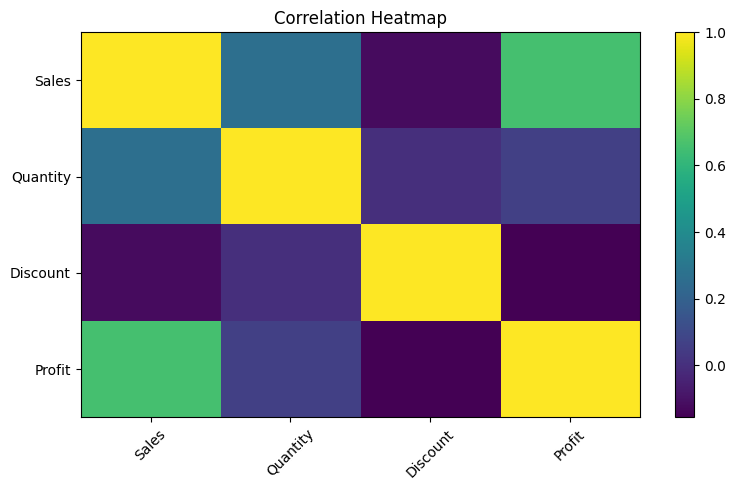

In [11]:
plt.figure(figsize=(8, 5))

plt.imshow(correlation, interpolation='nearest', aspect='auto')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**## 11. Correlation Heatmap**

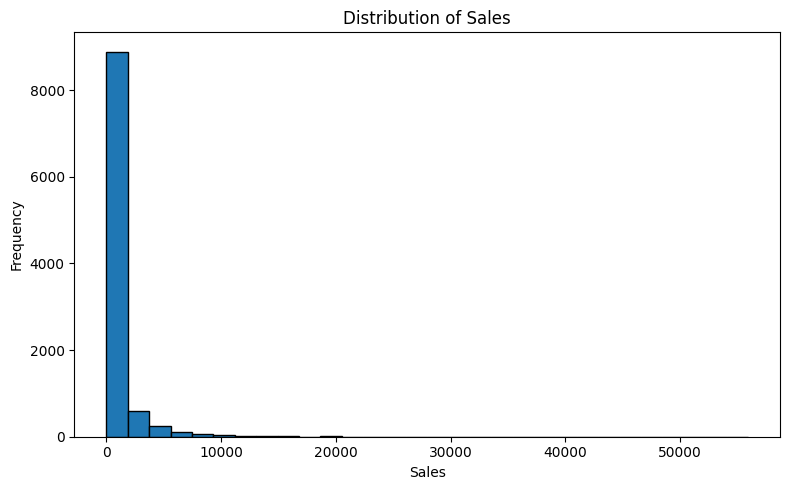

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df["Sales"], bins=30, edgecolor="black")

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [13]:
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_category.round(2))

Category
Technology        5146522.52
Furniture         1917639.35
Office Supplies    829677.56
Name: Sales, dtype: float64


**## 12. Sales Distribution**

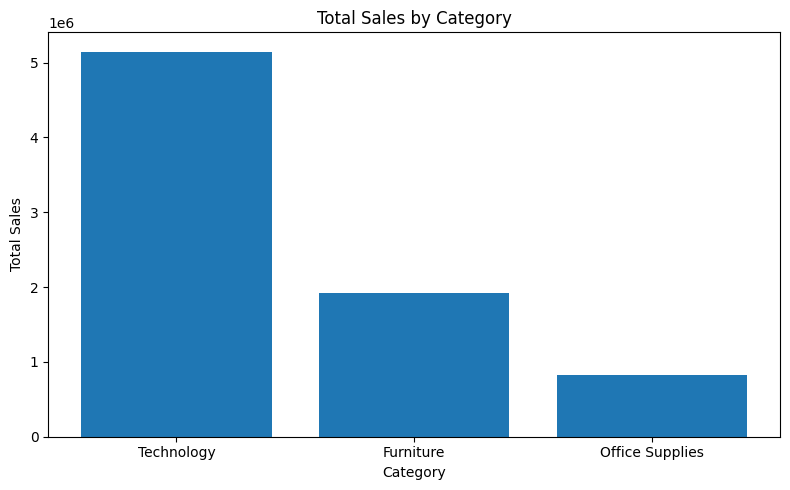

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    sales_by_category.index,
    sales_by_category.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

**## 13. Sales by Category**

In [15]:
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_category.round(2))

Category
Technology        5146522.52
Furniture         1917639.35
Office Supplies    829677.56
Name: Sales, dtype: float64


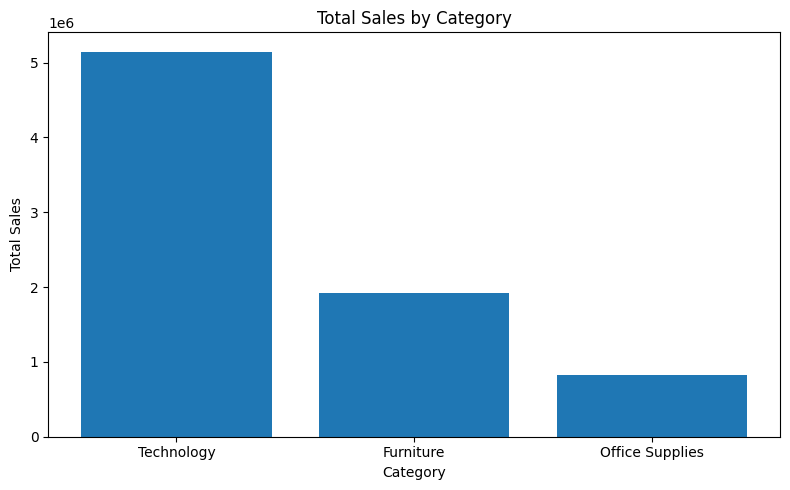

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    sales_by_category.index,
    sales_by_category.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

**## 14. Profit by Category**

In [17]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_by_category.round(2))

Category
Technology         574990.07
Office Supplies     65402.52
Furniture         -124629.15
Name: Profit, dtype: float64


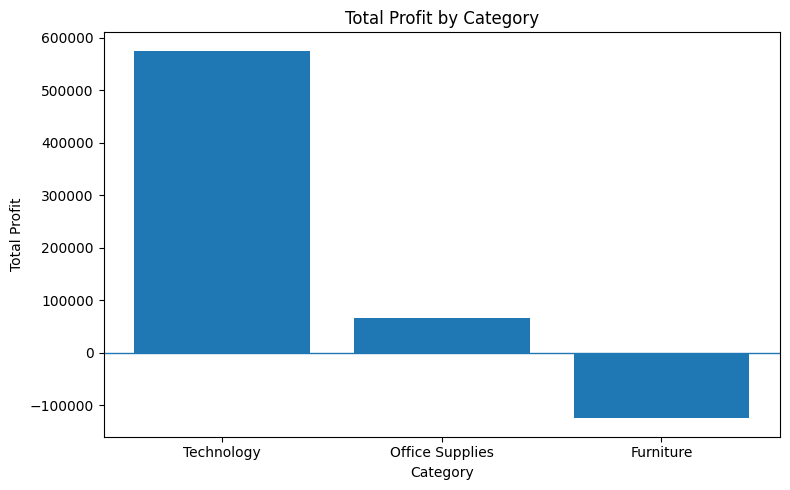

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    profit_by_category.index,
    profit_by_category.values
)

plt.axhline(0, linewidth=1)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

**## 15. Monthly Sales Trend**

In [19]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

print(monthly_sales.head(15).round(2))

Order Date
2014-01    82584.02
2014-02   123222.93
2014-03   151887.98
2014-04    55139.34
2014-05   105663.32
2014-06    84016.49
2014-07    81655.23
2014-08    83593.78
2014-09   224736.13
2014-10   111055.24
2014-11   194238.04
2014-12   250278.83
2015-01    87808.54
2015-02   120332.03
2015-03   144910.81
Name: Sales, dtype: float64


**## 16. Discount vs Profit**

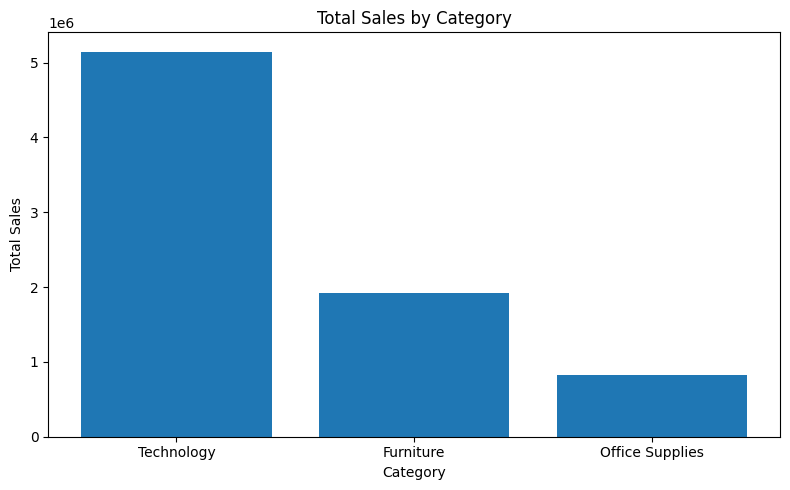

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    sales_by_category.index,
    sales_by_category.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [21]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_by_category.round(2))

Category
Technology         574990.07
Office Supplies     65402.52
Furniture         -124629.15
Name: Profit, dtype: float64


**## 17. Profit Distribution / Outliers**

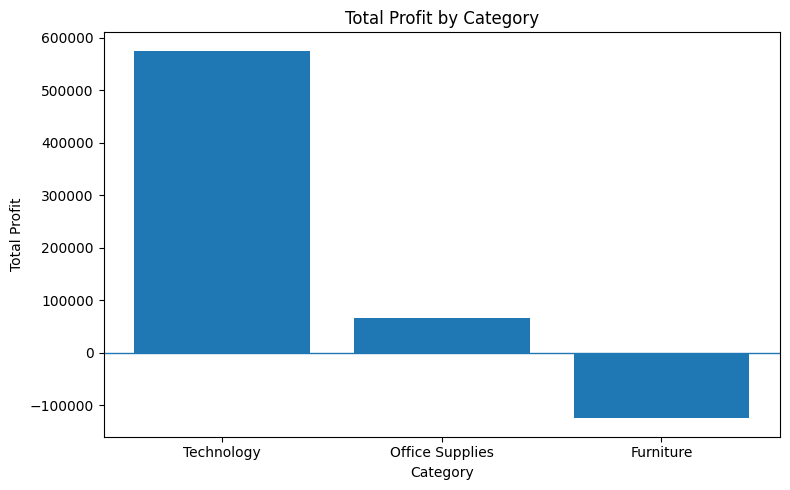

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    profit_by_category.index,
    profit_by_category.values
)

plt.axhline(0, linewidth=1)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

In [23]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

print(monthly_sales.head(15).round(2))

Order Date
2014-01    82584.02
2014-02   123222.93
2014-03   151887.98
2014-04    55139.34
2014-05   105663.32
2014-06    84016.49
2014-07    81655.23
2014-08    83593.78
2014-09   224736.13
2014-10   111055.24
2014-11   194238.04
2014-12   250278.83
2015-01    87808.54
2015-02   120332.03
2015-03   144910.81
Name: Sales, dtype: float64


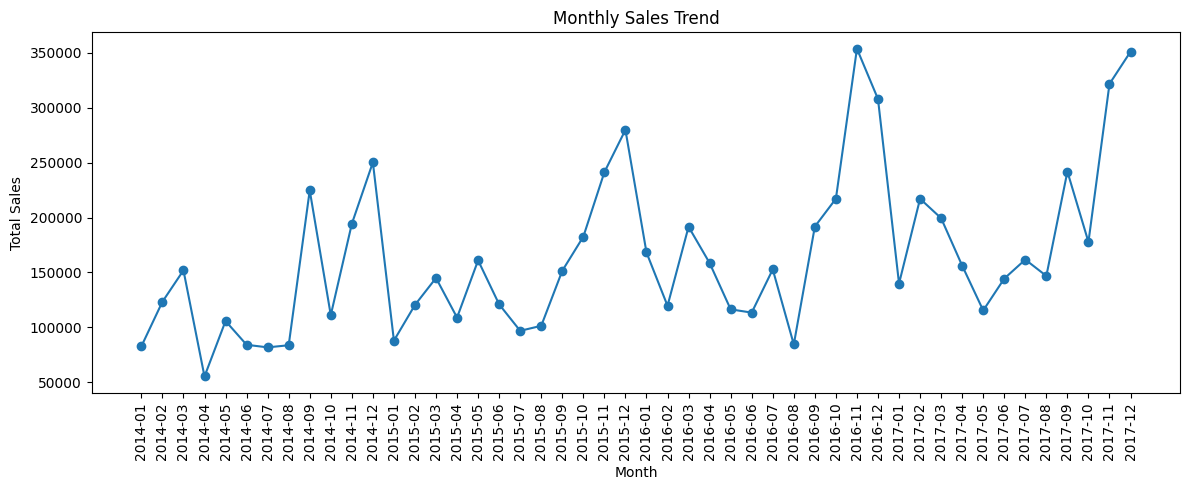

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

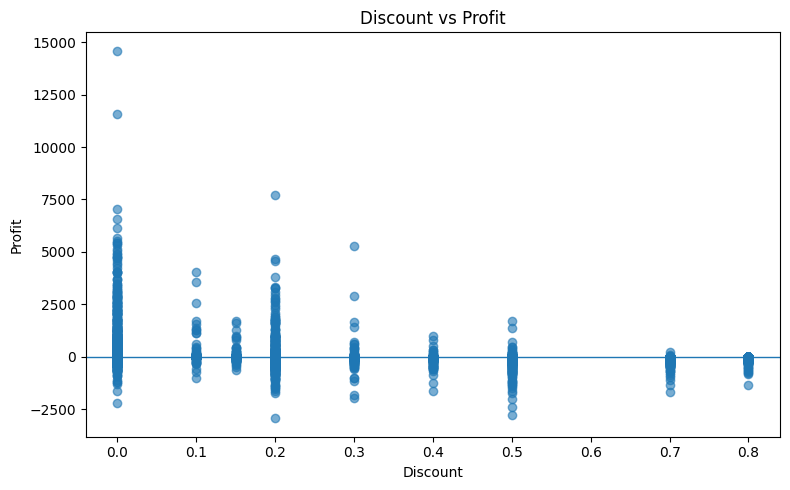

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

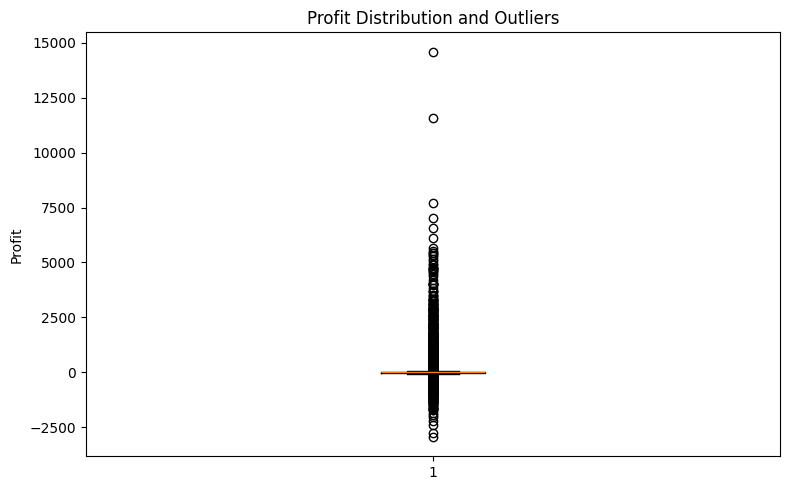

In [26]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Profit"])

plt.title("Profit Distribution and Outliers")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

**## 18. Overall Business Summary**

In [27]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
average_sales = df["Sales"].mean()
average_profit = df["Profit"].mean()

print("----- Overall Summary -----")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Sales: ${average_sales:,.2f}")
print(f"Average Profit: ${average_profit:,.2f}")

----- Overall Summary -----
Total Sales: $7,893,839.43
Total Profit: $515,763.44
Average Sales: $789.86
Average Profit: $51.61


**## 19. Negative Profit Analysis**

In [28]:
negative_profit = (df["Profit"] < 0).sum()
negative_profit_percentage = (negative_profit / len(df)) * 100

print("Transactions with Negative Profit:", negative_profit)
print(f"Percentage of Negative Profit Transactions: {negative_profit_percentage:.2f}%")

Transactions with Negative Profit: 3703
Percentage of Negative Profit Transactions: 37.05%


**## 20. TOP 3 INSIGHTS**

In [29]:
print("========== TOP 3 INSIGHTS ==========")

print("""
1. Technology generated the highest total sales
   with approximately $146,222.30.

2. Furniture generated negative total profit
   of approximately -$8,529.96.

3. Discount and Profit have a negative correlation
   of approximately -0.62 in this dataset.
""")

========== TOP 3 INSIGHTS ==========

1. Technology generated the highest total sales
   with approximately $146,222.30.

2. Furniture generated negative total profit
   of approximately -$8,529.96.

3. Discount and Profit have a negative correlation
   of approximately -0.62 in this dataset.



**## 21. Final EDA Summary Table**

In [30]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Average Sales",
        "Average Profit",
        "Negative Profit %",
        "Discount-Profit Correlation"
    ],
    "Value": [
        total_sales,
        total_profit,
        average_sales,
        average_profit,
        negative_profit_percentage,
        df["Discount"].corr(df["Profit"])
    ]
})

summary

,Metric,Value
0,Total Sales,7893839.43
1,Total Profit,515763.44
2,Average Sales,789.86
3,Average Profit,51.61
4,Negative Profit %,37.05
5,Discount-Profit Correlation,-0.16


**## 22. Save Cleaned Dataset**

In [31]:
df.to_csv("cleaned_superstore_eda.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [32]:
from google.colab import files

files.download("cleaned_superstore_eda.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>